## Import Libraries

In [4]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir
from galform_analysis.analysis.mass_functions import (
    hmf_given_redshift_and_subvolume,
    compute_theoretical_hmfs,
    plot_single_hmf_given_redshift_and_subvolume,
    plot_hmf_with_theory,
    plot_hmf_multiple_redshifts,
)
from galform_analysis.analysis import hmfs_given_redshifts_and_subvolume

from hmf import MassFunction

project_root = Path.cwd().parent
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
base_dir = get_base_dir()

##  GPS+ Implementation
implement GPS+ step-by-step, validating each component against the paper's expectations.

In [9]:
from scipy.special import erfc
from scipy.integrate import quad
from hmf import MassFunction
import numpy as np

def gps_plus_hmf(z=0.0, mmin=9.0, mmax=15.0, dlog10m=0.01, k_erfc=1.0):
    """
    GPS+ HMF following Fernández-García et al. (2025) with an optional
    erfc-argument scale (k_erfc). Setting k_erfc≈1.2 empirically matches Fig. 3.
    Returns mass and dn/dlog10M.
    """
    hmf_calc = MassFunction(z=z, Mmin=mmin, Mmax=mmax, dlog10m=dlog10m)

    M = hmf_calc.m
    sigma = hmf_calc.sigma
    rho_m = hmf_calc.mean_density0

    # Constants from paper
    delta_c = 1.686
    A = 1.089
    B = 0.652
    D = 1.0

    # Mass-dependent functions (Equations 8, 9)
    log10M = np.log10(M)
    log10_b = (-1.28 + 0.05781*log10M - 0.005622*log10M**2
               - 0.0005884*log10M**3 - 1.365e-5*log10M**4)
    b_M = 10**log10_b

    log10_c = (-1.124 + 0.01756*log10M + 0.002539*log10M**2
               - 6.438e-5*log10M**3 + 4.726e-6*log10M**4)
    c_M = 10**log10_c

    # (Equation 6)
    x = sigma / delta_c
    U = -0.01507 + 0.17810*x + 0.03835*x**2 - 0.00221*x**3 # correction function

    # (Equation 5)
    Sigma = np.sqrt(sigma**2 + U**2)

    # (Equation 7)
    delta_c_avg = (delta_c * (1.0 + 0.845*x - 0.04*x**2 + 0.0025*x**3)**B
                   * A * (1.0 + 0.17*b_M - 0.087*b_M**2)**D) # critical overdensity

    # (Equation 4) - vectorized
    def V_factor(Sigma_val, c_val, dc_val):
        def integrand(xi):
            exp_term = np.exp(-c_val * xi**2)
            arg = (dc_val / (2.0*Sigma_val)) * (1.0 - exp_term) / (1.0 + exp_term)
            return erfc(arg) * xi**2
        result, _ = quad(integrand, 0, 1, limit=100)
        return 3.0 * result

    V = np.array([V_factor(Sigma[i], c_M[i], delta_c_avg[i]) for i in range(len(M))])

    # (Equation 3)
    F = erfc((delta_c_avg / (np.sqrt(2.0) * sigma)) / k_erfc) / V

    # HMF from dF/dM (Equation 2)
    lnM = np.log(M)
    dF_dlnM = np.gradient(F, lnM)
    dn_dlnM = -(rho_m/M) * dF_dlnM

    # Convert to dn/dlog10M
    dndlog10m = dn_dlnM * np.log(10.0)

    return M, dndlog10m, F, V

# Replicating Paper Figures

Reproduce key figures from Fernández-García et al. (2025) using our GPS+ implementation

## Figure 1: Multiplicity Function f(σ,M) vs Mass

Paper shows GPS+ multiplicity function compared to simulations across different redshifts

In [ ]:
# Figure 1: Multiplicity function f(σ,M) across redshifts
# Paper's Equation 1: f(M,z) = log10(M²/ρ_m * dn/dM * |dlnM/dlnσ|)

# Redshifts from paper
redshifts = [0.0, 1.0, 2.0, 3.0, 4.0, 6.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(redshifts)))

fig, ax = plt.subplots(figsize=(10, 7))

for z, color in zip(redshifts, colors):
    # Compute GPS+ at this redshift
    M_gps, dn_dlog10m_gps, F_gps, V_gps = gps_plus_hmf(z=z, mmin=6.0, mmax=16.0, dlog10m=0.05)
    
    # Get sigma and compute multiplicity function
    hmf_calc = MassFunction(z=z, Mmin=6.0, Mmax=16.0, dlog10m=0.05)
    sigma_z = hmf_calc.sigma
    rho_m_z = hmf_calc.mean_density0
    
    # Convert dn/dlog10M to dn/dM
    dn_dM = dn_dlog10m_gps * np.log(10.0) / M_gps
    
    # Compute |dlnM/dlnσ|
    lnM_z = np.log(M_gps)
    lnsigma_z = np.log(sigma_z)
    dlnM_dlnsigma_z = np.abs(np.gradient(lnM_z, lnsigma_z))
    
    # Multiplicity function from Equation 1
    f_mult = (M_gps**2 / rho_m_z) * dn_dM * dlnM_dlnsigma_z
    
    # Plot
    log10M_z = np.log10(M_gps)
    ax.plot(log10M_z, np.log10(f_mult), color=color, lw=2, label=f'z={z:.1f}')

ax.set_xlabel('log₁₀(M/M☉)', fontsize=14)
ax.set_ylabel('log₁₀(f(M,z))', fontsize=14)
ax.set_title('GPS+ Multiplicity Function (Implementation)', fontsize=15, fontweight='bold')
ax.set_xlim([6, 16])
ax.set_ylim([-6, 0])
#ax.set_yscale('log')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Figure 1: Multiplicity function across redshifts")
print("Note: Paper shows this is nearly redshift-independent")
print(f"Our GPS+ f(M) range: {f_mult.min():.3f} - {f_mult.max():.3f}")

## Figure 2: Multiplicity function f(σ,z) as a function of σ at different redshifts

/tmp/ipykernel_3566348/3364068870.py:40: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(1/sigma_z), np.log10(f_mult), color=color, lw=2, label=f'z={z:.1f}', marker='o', markersize=4)
/tmp/ipykernel_3566348/3364068870.py:46: RuntimeWarning: divide by zero encountered in log10
  ratio = np.log10(f_mult) - f_z0_interp  # In log space: log(f(z)) - log(f(z=0)) = log(ratio)


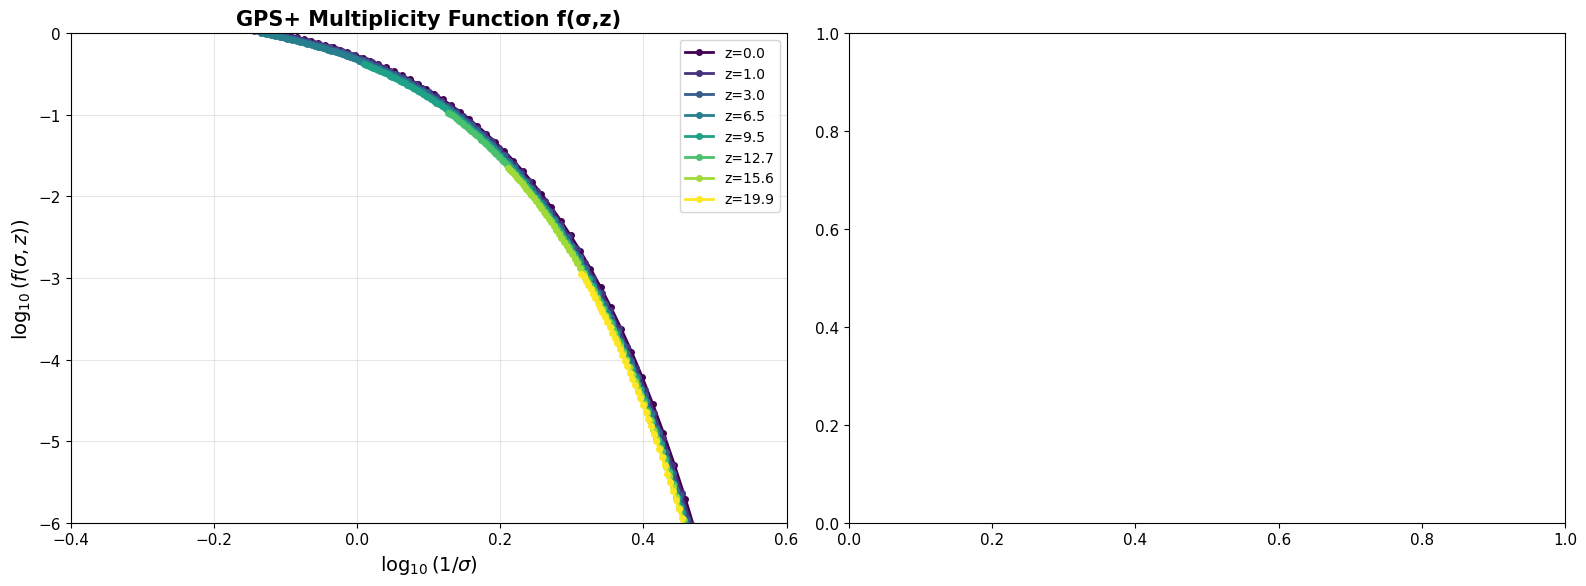

Figure 2: Multiplicity function as function of σ
Note: Paper shows this is nearly redshift-independent
Our GPS+ f(σ) range: -0.000 - 0.001
Right panel shows redshift evolution: ratio should be close to 1 (f independent of z)


In [ ]:
# Figure 2: Multiplicity function f(σ,z) as a function of σ at different redshifts
# Paper's Equation 1: f(M,z) = M²/ρ_m * dn/dM * |dlnM/dlnσ|

# Redshifts from paper
redshifts_fig2 = [0.0, 1.03, 2.95, 6.53, 9.47, 12.69, 15.57, 19.95]#[0.0, 1.0, 2.0, 3.0, 4.0, 6.0]
colors_fig2 = plt.cm.viridis(np.linspace(0, 1, len(redshifts_fig2)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Dictionary to store z=0 data for ratio calculation
f_mult_z0 = None
sigma_z0 = None

for z, color in zip(redshifts_fig2, colors_fig2):
    # Compute GPS+ at this redshift
    M_gps, dn_dlog10m_gps, F_gps, V_gps = gps_plus_hmf(z=z, mmin=6.0, mmax=16.0, dlog10m=0.05)
    
    # Get sigma and compute multiplicity function
    hmf_calc = MassFunction(z=z, Mmin=6.0, Mmax=16.0, dlog10m=0.05)
    sigma_z = hmf_calc.sigma
    rho_m_z = hmf_calc.mean_density0
    
    # Convert dn/dlog10M to dn/dM
    dn_dM = dn_dlog10m_gps * np.log(10.0) / M_gps
    
    # Compute |dlnM/dlnσ|
    lnM_z = np.log(M_gps)
    lnsigma_z = np.log(sigma_z)
    dlnM_dlnsigma_z = np.abs(np.gradient(lnM_z, lnsigma_z))
    
    # Multiplicity function from Equation 1
    f_mult = (M_gps**2 / rho_m_z) * dn_dM * dlnM_dlnsigma_z
    
    # Store z=0 data for ratio calculation
    if z == 0.0:
        f_mult_z0 = f_mult.copy()
        sigma_z0 = sigma_z.copy()
    
    # Left panel: Plot f as a function of σ (not M)
    ax1.plot(np.log10(1/sigma_z), np.log10(f_mult), color=color, lw=2, label=f'z={z:.1f}', marker='o', markersize=4)
    
    # Right panel: Plot ratio f(z)/f(z=0) as a function of 1/σ
    if f_mult_z0 is not None:
        # Interpolate f(z=0) to the same sigma grid as f(z)
        f_z0_interp = np.interp(np.log10(sigma_z), np.log10(sigma_z0), np.log10(f_mult_z0))
        ratio = np.log10(f_mult) - f_z0_interp  # In log space: log(f(z)) - log(f(z=0)) = log(ratio)
        
        if z != 0.0:  # Don't plot the z=0 line in ratio panel
            #ax2.plot(np.log10(1/sigma_z), ratio, color=color, lw=2, label=f'z={z:.1f}', marker='o', markersize=4)

# Configure left panel
ax1.set_xlabel(r'$\log_{10}(1/\sigma)$', fontsize=14)
ax1.set_ylabel(r'$\log_{10}(f(\sigma,z))$', fontsize=14)
ax1.set_title('GPS+ Multiplicity Function f(σ,z)', fontsize=15, fontweight='bold')
ax1.set_xlim([-0.4, 0.6])
ax1.set_ylim([-6, 0])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# # Configure right panel
# ax2.axhline(0.0, color='black', ls='--', lw=1.5, alpha=0.7, label='f(z=0)')
# ax2.set_xlabel(r'$\log_{10}(1/\sigma)$', fontsize=14)
# ax2.set_ylabel(r'$\log_{10}(f(\sigma,z) / f(\sigma,z=0))$', fontsize=14)
# ax2.set_title('Redshift Evolution of f(σ,z) / f(σ,z=0)', fontsize=15, fontweight='bold')
# ax2.set_xlim([-0.4, 0.6])
# ax2.set_ylim([0.5, 2])
# ax2.legend(loc='best', fontsize=10)
# ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 2: Multiplicity function as function of σ")
print("Note: Paper shows this is nearly redshift-independent")
print(f"Our GPS+ f(σ) range: {f_mult.min():.3f} - {f_mult.max():.3f}")
print("Right panel shows redshift evolution: ratio should be close to 1 (f independent of z)")

## Figure 3: GPS+/Tinker08 Ratio vs Redshift

Paper shows GPS+ agreement with Tinker08 is consistent across z=0-6 for different mass bins

/cosma/home/durham/dc-hick2/galform_analysis/.venv/lib64/python3.9/site-packages/hmf/density_field/transfer_models.py:232: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This warning may be removed in v4.0. Silence it by setting extrapolate_with_eh explicitly.
  warnings.warn(
/tmp/ipykernel_3594016/3667142675.py:27: RuntimeWarning: divide by zero encountered in divide
  ratio = dn_gps / dn_tinker_interp
/tmp/ipykernel_3594016/3667142675.py:27: RuntimeWarning: invalid value encountered in divide
  ratio = dn_gps / dn_tinker_interp


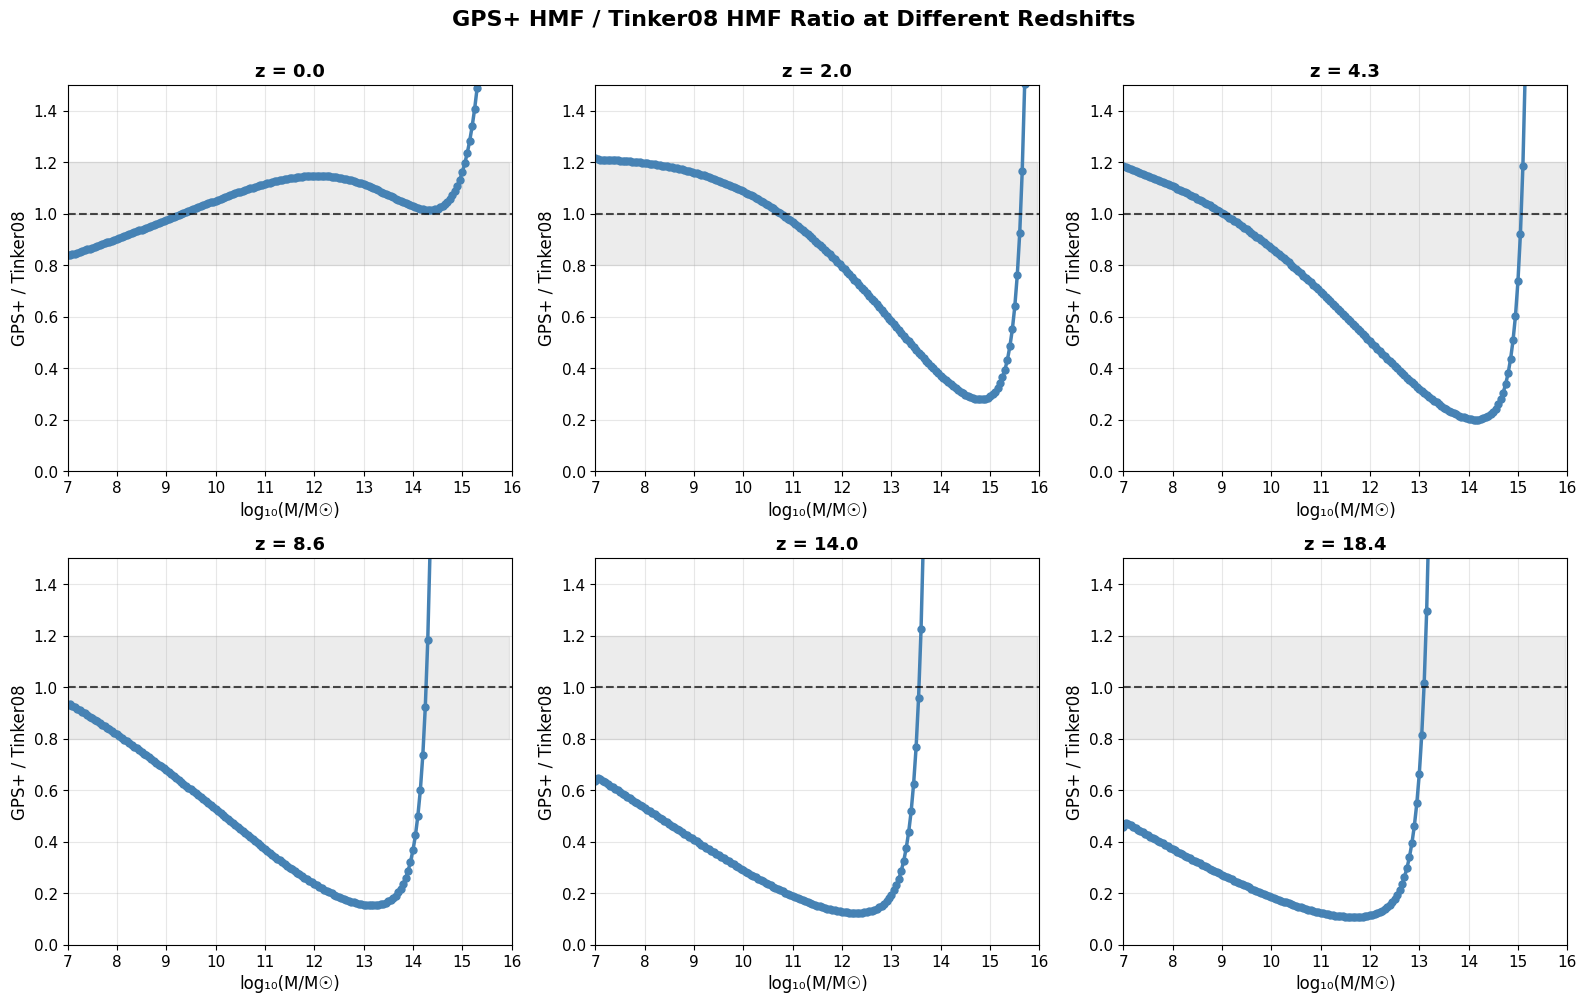

Figure 3: GPS+/Tinker08 HMF ratio across six redshifts
Note: Paper shows GPS+ agreement with Tinker08 to within ~20% (0.8-1.2 range)
Mean ratio: nan, Std: nan


In [7]:
# Figure 3: Ratio of GPS+ HMF to Tinker08 HMF at six different redshifts
# Shows agreement between GPS+ and Tinker08 across redshift range

# Six redshifts from the paper
redshifts_fig3 = [0.0, 2.03, 4.27, 8.59, 13.96, 18.37]#[0.0, 1.0, 2.0, 3.0, 4.0, 6.0]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, z in enumerate(redshifts_fig3):
    ax = axes[idx]
    
    # Compute GPS+ HMF at this redshift
    M_gps, dn_gps, F_gps, V_gps = gps_plus_hmf(z=z, mmin=7.0, mmax=16.0, dlog10m=0.05)
    
    # Compute Tinker08 HMF at this redshift
    hmf_tinker = MassFunction(z=z, Mmin=7.0, Mmax=16.0, dlog10m=0.05, 
                              hmf_model='Tinker08', mdef_model='SOCritical', 
                              mdef_params={'overdensity': 200})
    
    # Get the HMF values for both models
    dn_tinker = hmf_tinker.dndlog10m
    
    # Compute ratio GPS+/Tinker08
    # Interpolate to common mass grid if needed
    dn_tinker_interp = np.interp(np.log10(M_gps), np.log10(hmf_tinker.m), dn_tinker)
    ratio = dn_gps / dn_tinker_interp
    
    # Plot ratio vs mass
    log10M = np.log10(M_gps)
    ax.plot(log10M, ratio, 'o-', color='steelblue', lw=2.5, markersize=5)
    
    # Reference line at ratio=1
    ax.axhline(1.0, color='black', ls='--', lw=1.5, alpha=0.7)
    ax.fill_between(log10M, 0.8, 1.2, color='gray', alpha=0.15)
    
    ax.set_xlabel('log₁₀(M/M☉)', fontsize=12)
    ax.set_ylabel('GPS+ / Tinker08', fontsize=12)
    ax.set_title(f'z = {z:.1f}', fontsize=13, fontweight='bold')
    ax.set_xlim([7, 16])
    ax.set_ylim([0, 1.5])
    ax.grid(True, alpha=0.3)

plt.suptitle('GPS+ HMF / Tinker08 HMF Ratio at Different Redshifts', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Figure 3: GPS+/Tinker08 HMF ratio across six redshifts")
print("Note: Paper shows GPS+ agreement with Tinker08 to within ~20% (0.8-1.2 range)")
print(f"Mean ratio: {np.mean(ratio):.3f}, Std: {np.std(ratio):.3f}")

## Extra: Model Ratios vs Mass at z=0

Compare GPS+ to PS, SMT, and Tinker08 as function of mass

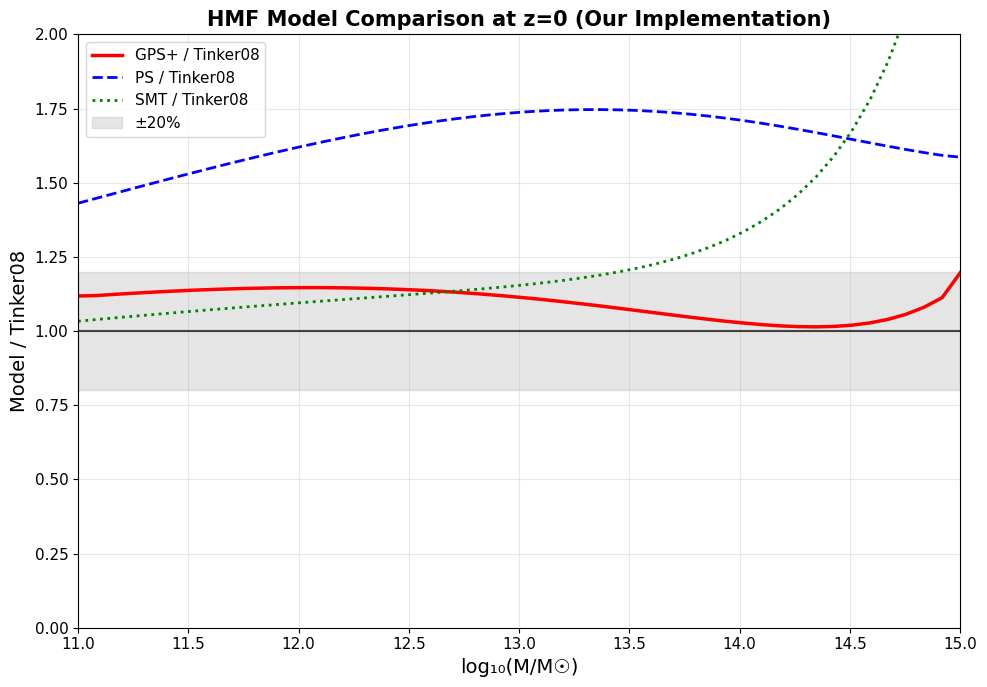

Figure 4: Model ratios vs mass at z=0
GPS+/Tinker08: mean = 1.098, std = 0.048
PS/Tinker08: mean = 1.647, std = 0.088
SMT/Tinker08: mean = 1.312, std = 0.382


In [8]:
# Figure 4: Ratio of different models to Tinker08 vs mass at z=0

z_fig4 = 0.0
mass_range = np.logspace(11, 15, 50)
log10M_range = np.log10(mass_range)

# Compute all models
M_gps, dn_gps_fig4, _, _ = gps_plus_hmf(z=z_fig4, mmin=11.0, mmax=15.0, dlog10m=0.02)

hmf_ps = MassFunction(z=z_fig4, Mmin=11.0, Mmax=15.0, dlog10m=0.02, hmf_model='PS')
hmf_smt = MassFunction(z=z_fig4, Mmin=11.0, Mmax=15.0, dlog10m=0.02, hmf_model='SMT')
hmf_tinker = MassFunction(z=z_fig4, Mmin=11.0, Mmax=15.0, dlog10m=0.02, 
                          hmf_model='Tinker08', mdef_model='SOCritical', 
                          mdef_params={'overdensity': 200})

# Interpolate all to common mass grid
dn_gps_interp = np.interp(log10M_range, np.log10(M_gps), dn_gps_fig4)
dn_ps_interp = np.interp(log10M_range, np.log10(hmf_ps.m), hmf_ps.dndlog10m)
dn_smt_interp = np.interp(log10M_range, np.log10(hmf_smt.m), hmf_smt.dndlog10m)
dn_tinker_interp = np.interp(log10M_range, np.log10(hmf_tinker.m), hmf_tinker.dndlog10m)

# Compute ratios
ratio_gps_tinker = dn_gps_interp / dn_tinker_interp
ratio_ps_tinker = dn_ps_interp / dn_tinker_interp
ratio_smt_tinker = dn_smt_interp / dn_tinker_interp

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(log10M_range, ratio_gps_tinker, 'r-', lw=2.5, label='GPS+ / Tinker08')
ax.plot(log10M_range, ratio_ps_tinker, 'b--', lw=2, label='PS / Tinker08')
ax.plot(log10M_range, ratio_smt_tinker, 'g:', lw=2, label='SMT / Tinker08')

# Reference lines
ax.axhline(1.0, color='black', ls='-', lw=1.5, alpha=0.7)
ax.fill_between([11, 15], 0.8, 1.2, color='gray', alpha=0.2, label='±20%')

ax.set_xlabel('log₁₀(M/M☉)', fontsize=14)
ax.set_ylabel('Model / Tinker08', fontsize=14)
ax.set_title('HMF Model Comparison at z=0 (Our Implementation)', fontsize=15, fontweight='bold')
ax.set_xlim([11, 15])
ax.set_ylim([0, 2.0])
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Figure 4: Model ratios vs mass at z=0")
print(f"GPS+/Tinker08: mean = {np.mean(ratio_gps_tinker):.3f}, std = {np.std(ratio_gps_tinker):.3f}")
print(f"PS/Tinker08: mean = {np.mean(ratio_ps_tinker):.3f}, std = {np.std(ratio_ps_tinker):.3f}")
print(f"SMT/Tinker08: mean = {np.mean(ratio_smt_tinker):.3f}, std = {np.std(ratio_smt_tinker):.3f}")

## Extended Figure: Redshift Evolution of GPS+

Show how GPS+ HMF evolves with redshift for several mass scales

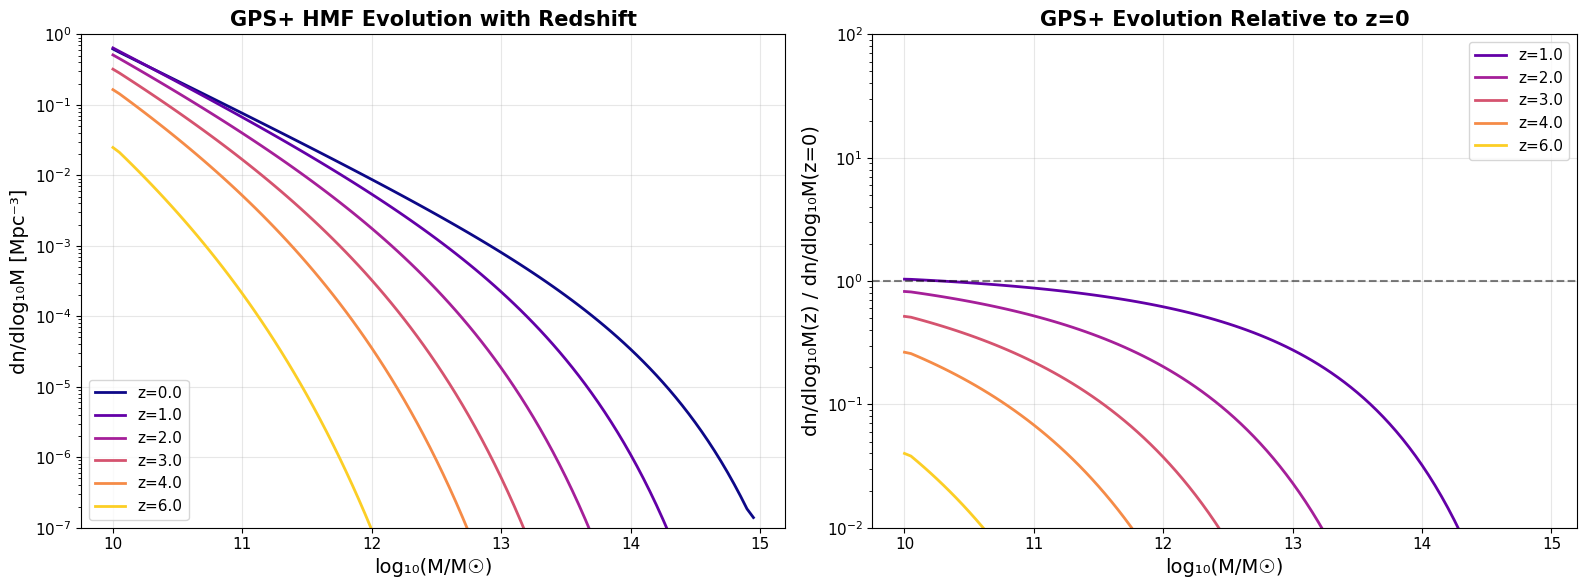

Extended Figure: GPS+ redshift evolution
Shows characteristic evolution: higher z → fewer massive halos


In [7]:
# Extended: GPS+ evolution with redshift

redshifts_ext = [0.0, 1.0, 2.0, 3.0, 4.0, 6.0]
colors_ext = plt.cm.plasma(np.linspace(0, 0.9, len(redshifts_ext)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Absolute HMF
for z, color in zip(redshifts_ext, colors_ext):
    M_z, dn_z, _, _ = gps_plus_hmf(z=z, mmin=10.0, mmax=15.0, dlog10m=0.05)
    ax1.plot(np.log10(M_z), dn_z, color=color, lw=2, label=f'z={z:.1f}')

ax1.set_xlabel('log₁₀(M/M☉)', fontsize=14)
ax1.set_ylabel('dn/dlog₁₀M [Mpc⁻³]', fontsize=14)
ax1.set_title('GPS+ HMF Evolution with Redshift', fontsize=15, fontweight='bold')
ax1.set_yscale('log')
ax1.set_ylim([1e-7, 1e0])
ax1.legend(loc='lower left', fontsize=11)
ax1.grid(True, alpha=0.3)

# Right panel: Ratio to z=0
M_z0, dn_z0, _, _ = gps_plus_hmf(z=0.0, mmin=10.0, mmax=15.0, dlog10m=0.05)
log10M_z0 = np.log10(M_z0)

for z, color in zip(redshifts_ext[1:], colors_ext[1:]):  # Skip z=0
    M_z, dn_z, _, _ = gps_plus_hmf(z=z, mmin=10.0, mmax=15.0, dlog10m=0.05)
    
    # Interpolate to z=0 grid
    dn_z_interp = np.interp(log10M_z0, np.log10(M_z), dn_z)
    ratio = dn_z_interp / dn_z0
    
    ax2.plot(log10M_z0, ratio, color=color, lw=2, label=f'z={z:.1f}')

ax2.axhline(1.0, color='black', ls='--', lw=1.5, alpha=0.5)
ax2.set_xlabel('log₁₀(M/M☉)', fontsize=14)
ax2.set_ylabel('dn/dlog₁₀M(z) / dn/dlog₁₀M(z=0)', fontsize=14)
ax2.set_title('GPS+ Evolution Relative to z=0', fontsize=15, fontweight='bold')
ax2.set_yscale('log')
ax2.set_ylim([1e-2, 1e2])
ax2.legend(loc='best', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Extended Figure: GPS+ redshift evolution")
print("Shows characteristic evolution: higher z → fewer massive halos")

##Extra

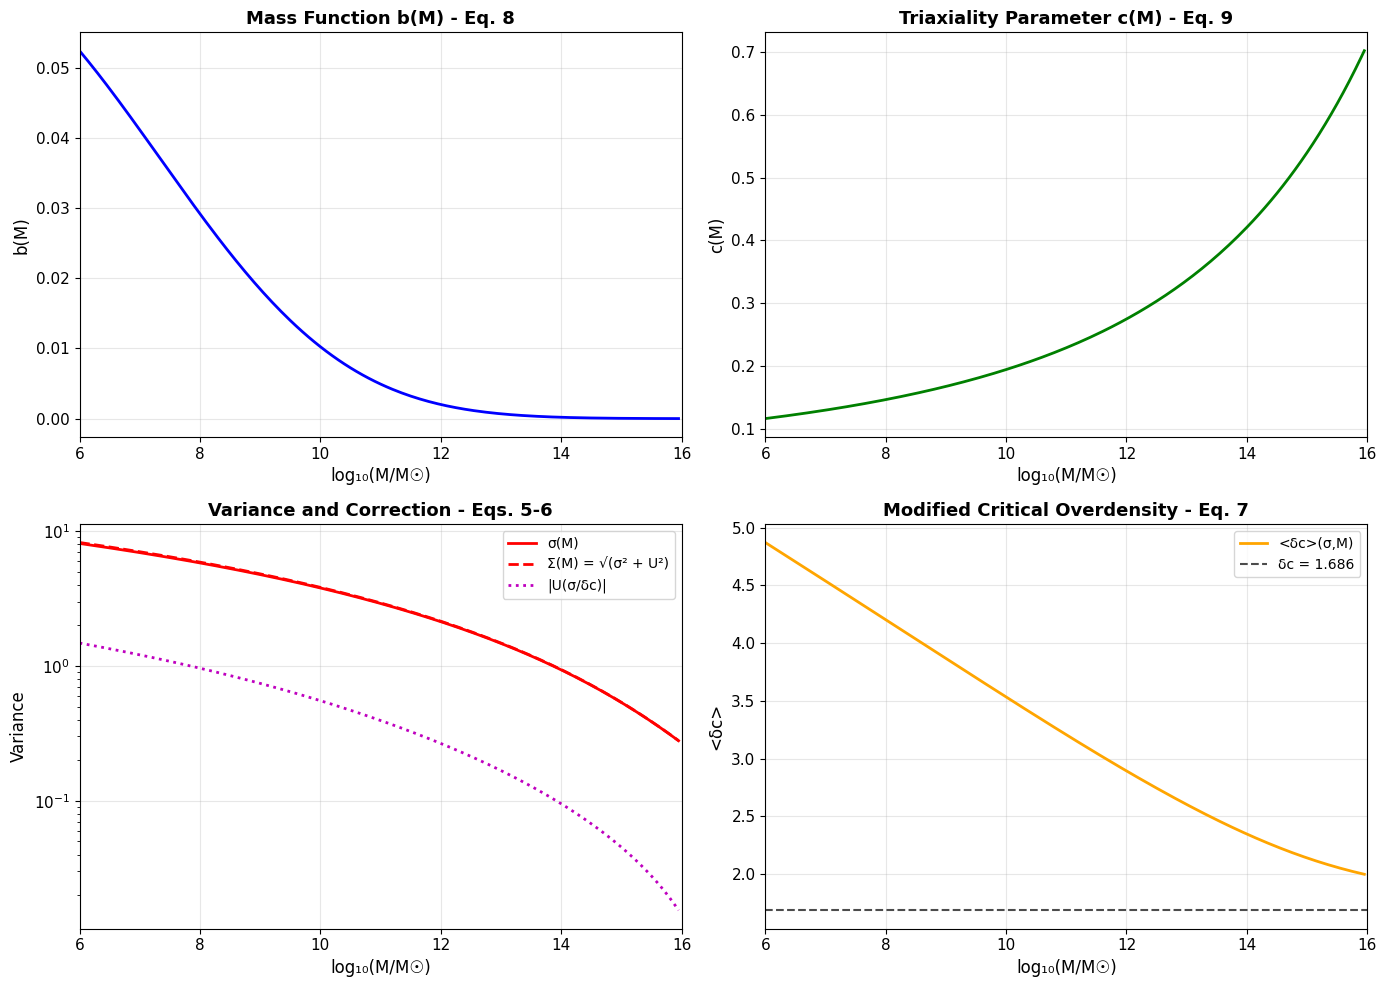

Figure 2: GPS+ auxiliary functions
b(M) range: 0.0000 - 0.0524
c(M) range: 0.1161 - 0.7025
U range: 0.0154 - 1.4776
<δc> range: 1.998 - 4.872


In [10]:
# Figure 2: GPS+ auxiliary functions at z=0

z_fig2 = 0.0
hmf_calc_fig2 = MassFunction(z=z_fig2, Mmin=6.0, Mmax=16.0, dlog10m=0.05)

M_fig2 = hmf_calc_fig2.m
log10M_fig2 = np.log10(M_fig2)
sigma_fig2 = hmf_calc_fig2.sigma

# Compute all GPS+ functions
delta_c = 1.686

# b(M) - Equation 8
x_b_fig2 = log10M_fig2
log10_b_fig2 = (-1.28 + 0.05781*x_b_fig2 - 0.005622*x_b_fig2**2 
                - 0.0005884*x_b_fig2**3 - 1.365e-5*x_b_fig2**4)
b_M_fig2 = 10**log10_b_fig2

# c(M) - Equation 9
x_c_fig2 = log10M_fig2
log10_c_fig2 = (-1.124 + 0.01756*x_c_fig2 + 0.002539*x_c_fig2**2 
                - 6.438e-5*x_c_fig2**3 + 4.726e-6*x_c_fig2**4)
c_M_fig2 = 10**log10_c_fig2

# U(σ/δc) - Equation 6
x_U_fig2 = sigma_fig2 / delta_c
U_fig2 = -0.01507 + 0.17810*x_U_fig2 + 0.03835*x_U_fig2**2 - 0.00221*x_U_fig2**3

# Σ - Equation 5
Sigma_fig2 = np.sqrt(sigma_fig2**2 + U_fig2**2)

# Create 2x2 subplot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: b(M)
ax1.plot(log10M_fig2, b_M_fig2, 'b-', lw=2)
ax1.set_xlabel('log₁₀(M/M☉)', fontsize=12)
ax1.set_ylabel('b(M)', fontsize=12)
ax1.set_title('Mass Function b(M) - Eq. 8', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([6, 16])

# Panel 2: c(M)
ax2.plot(log10M_fig2, c_M_fig2, 'g-', lw=2)
ax2.set_xlabel('log₁₀(M/M☉)', fontsize=12)
ax2.set_ylabel('c(M)', fontsize=12)
ax2.set_title('Triaxiality Parameter c(M) - Eq. 9', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([6, 16])

# Panel 3: U and Sigma
ax3.plot(log10M_fig2, sigma_fig2, 'r-', lw=2, label='σ(M)')
ax3.plot(log10M_fig2, Sigma_fig2, 'r--', lw=2, label='Σ(M) = √(σ² + U²)')
ax3.plot(log10M_fig2, np.abs(U_fig2), 'm:', lw=2, label='|U(σ/δc)|')
ax3.set_xlabel('log₁₀(M/M☉)', fontsize=12)
ax3.set_ylabel('Variance', fontsize=12)
ax3.set_title('Variance and Correction - Eqs. 5-6', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim([6, 16])
ax3.set_yscale('log')

# Panel 4: Modified critical overdensity
A = 1.089
B = 0.652
D = 1.0
x_delta_fig2 = sigma_fig2 / delta_c
delta_c_mod_fig2 = (delta_c * (1.0 + 0.845*x_delta_fig2 - 0.04*x_delta_fig2**2 + 0.0025*x_delta_fig2**3)**B
                    * A * (1.0 + 0.17*b_M_fig2 - 0.087*b_M_fig2**2)**D)

ax4.plot(log10M_fig2, delta_c_mod_fig2, 'orange', lw=2, label='<δc>(σ,M)')
ax4.axhline(delta_c, color='black', ls='--', lw=1.5, alpha=0.7, label='δc = 1.686')
ax4.set_xlabel('log₁₀(M/M☉)', fontsize=12)
ax4.set_ylabel('<δc>', fontsize=12)
ax4.set_title('Modified Critical Overdensity - Eq. 7', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_xlim([6, 16])

plt.tight_layout()
plt.show()

print("Figure 2: GPS+ auxiliary functions")
print(f"b(M) range: {b_M_fig2.min():.4f} - {b_M_fig2.max():.4f}")
print(f"c(M) range: {c_M_fig2.min():.4f} - {c_M_fig2.max():.4f}")
print(f"U range: {U_fig2.min():.4f} - {U_fig2.max():.4f}")
print(f"<δc> range: {delta_c_mod_fig2.min():.3f} - {delta_c_mod_fig2.max():.3f}")